In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import descri_function as des_fun

In [2]:
# dado com os modelos 
#df = pd.read_parquet("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_27_03_2026_with_MEM_EVI.parquet")
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_06_05_2026_with_MEM_all_mods_ens.parquet')

dta = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/cities_valid_for_MEM_26_03_2026.parquet')


#df_ens_and = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/resultado_13-04-2026_mlp_xgb_withConsec.parquet')
df_ens_and = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/resultado_predicoes_producao_mlp.parquet')

df_ens_and = df_ens_and[['co_ibge', 'year_week','prob_ensemble_xgb', 'signal_ensemble_xgb50', 'prob_ensemble_mlp',
       'signal_ensemble_mlp50']]
#df_ens_and = df_ens_and.rename(columns={'prob_ensemble_xgb':'prob_ensemble_xgb2', 'signal_ensemble_xgb50': 'signal_ensemble_xgb502', 
#                           'prob_ensemble_mlp':'prob_ensemble_mlp2', 'signal_ensemble_mlp50':'signal_ensemble_mlp502'})

df_merged = df.merge(df_ens_and, on=['co_ibge', 'year_week'], how='inner')

df = df_merged.copy()

# Select cities for the manuscript analysis (valid MEM)
lst = list(set(df.co_ibge.unique()) - set(dta.co_ibge.unique()))
df = df[~df.co_ibge.isin(lst)]

df =  df[(df.year_week >= '2022-42') &(df.year_week <= '2025-32')]

In [3]:
# Set intensity
df_mem = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/mem_output_26_03_2026.parquet')

df_mem = df_mem[df_mem.epiyear.isin([2022,2023, 2024,2025])]

dta_intens = df_mem.groupby(['co_ibge'])[['baseline', 'post_baseline', 'epidemic_threshold',
       'post_threshold', 'low_level', 'medium_level', 'high_level']].max().reset_index()

# FUNCTION TO ASSIGN INTENSITY

def classify_block(values):
    
    # Check from most severe to least
    if (values > high).any():
        return 'very high'
    
    elif (values > med).any():
        return 'high'
    
    elif (values > low).any():
        return 'medium'
    
    elif (values > epi).any():
        return 'low'
    
    elif ((values > base) & (values <= epi)).any():
        return 'very low'
    
    elif (values <= base).any():
        return 'baseline'
    
    return np.nan


In [4]:
import warnings
warnings.filterwarnings('ignore')

lst = []

for code in df.co_ibge.unique():

    #print(code)

    set_muni = df[df.co_ibge == code].copy()
    set_muni_inten = dta_intens[dta_intens.co_ibge == code]

    thresholds = set_muni_inten.iloc[0]

    base = thresholds['baseline'].astype(int)
    epi = thresholds['epidemic_threshold'].astype(int)
    low = thresholds['low_level'].astype(int)
    med = thresholds['medium_level'].astype(int)
    high = thresholds['high_level'].astype(int)
    very_high = thresholds.get('very_high_level', np.inf)  # fallback if missing


    set_muni = set_muni.sort_values(['year_week'])

    # IDENTIFY BLOCKS

    flag = set_muni['mem_surge_01_correct_with_consec']

    # Create block IDs for consecutive 1s
    set_muni['block'] = (flag != flag.shift()).cumsum()

    # Keep only blocks where flag == 1
    set_muni['intensity'] = np.nan


    #  APPLY TO EACH BLOCK

    for block_id, group in set_muni.groupby('block'):
    
        if group['mem_surge_01_correct_with_consec'].iloc[0] != 1:
            continue
    
        values = group['atend_ivas']
    
        intensity_label = classify_block(values)
    
        set_muni.loc[group.index, 'intensity'] = intensity_label

    lst.append(set_muni)


In [5]:
result = pd.concat(lst)
result['mem_low'] = ((result['intensity'] == 'low') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_medium'] = ((result['intensity'] == 'medium') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_high'] = ((result['intensity'] == 'high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_very_high'] = ((result['intensity'] == 'very high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)

In [6]:
result.columns

Index(['co_ibge', 'epiweek', 'year', 'year_week', 'week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'sinal_evi_ivas',
       'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM', 'EWS_COPOD', 'EWS_Rt',
       'hard_voting_ivas', 'sinal_ears_atend_lag_1', 'sinal_ears_atend_lag_2',
       'sinal_ears_atend_lag_3', 'sinal_evi_ivas_lag_1',
       'sinal_evi_ivas_lag_2', 'sinal_evi_ivas_lag_3', 'EWS_ISF_lag_1',
       'EWS_ISF_lag_2', 'EWS_ISF_lag_3', 'EWS_LOF_lag_1', 'EWS_LOF_lag_2',
       'EWS_LOF_lag_3', 'EWS_OCSVM_lag_1', 'EWS_OCSVM_lag_2',
       'EWS_OCSVM_lag_3', 'EWS_COPOD_lag_1', 'EWS_COPOD_lag_2',
       'EWS_COPOD_lag_3', 'EWS_Rt_lag_1', 'EWS_Rt_lag_2', 'EWS_Rt_lag_3',
       'risk_probs', 'sinal_ens_ivas_new', 'prob_ensemble_xgb',
       'signal_ensemble_xgb50', 'prob_ensemble_mlp', 'signal_ensemble_mlp50',
       'block', 'intensity', 'mem_low', 'mem_medium', 'mem_high',
       'mem_very_high'],
      dtype='

In [7]:
result = result[['co_ibge', 'year_week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'sinal_evi_ivas',
       'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM', 'EWS_COPOD', 'EWS_Rt',
       'prob_ensemble_xgb', 'signal_ensemble_xgb50', 'prob_ensemble_mlp',
       'signal_ensemble_mlp50', 'hard_voting_ivas', 
       'risk_probs', 'sinal_ens_ivas_new', 'block', 'intensity', 'mem_low',
       'mem_medium', 'mem_high', 'mem_very_high']]

In [18]:
# select period

data = result[result.year_week >= '2025-01']


models = ['sinal_ears_atend',
          'sinal_evi_ivas',
          'EWS_ISF', 
          'EWS_LOF', 
          'EWS_OCSVM', 
          'EWS_COPOD', 
          'EWS_Rt',
          'signal_ensemble_xgb50',
          'signal_ensemble_mlp50',
          'sinal_ens_ivas_new',
          'hard_voting_ivas'
]

warn_col = 'warning_final_mem_surge_01'

warn_col_with_consec = 'mem_surge_01_correct_with_consec'

# Compare models

In [19]:
data = data.rename(columns={'EWS_COPOD': 'COPOD', 'EWS_ISF': 'ISF',
                         'EWS_LOF':'LOF', 'EWS_OCSVM': 'OCSVM',
                         'EWS_Rt':'NGM', 'sinal_ears_atend': 'EARS',
                         'sinal_evi_ivas': 'EVI', 'signal_ensemble_xgb50': 'XGB',
                         'signal_ensemble_mlp50':'MLP', 'sinal_ens_ivas_new': 'LR',
                                            'hard_voting_ivas': 'Hard Voting'})


In [20]:
# Lista dos seus modelos
models = ['EARS', 'EVI', 'ISF', 'LOF', 'OCSVM', 'COPOD', 'NGM']

# Calculando a correlação de Pearson (para binários, o coeficiente Phi é equivalente)
corr = data[models].corr()

In [21]:
data[models].sum()

EARS     49654
EVI      36746
ISF      23626
LOF      26385
OCSVM    24997
COPOD    23049
NGM      29763
dtype: int64

In [22]:
data[['XGB','LR','MLP','Hard Voting']].sum()

XGB            49946
LR             47836
MLP            52264
Hard Voting    27676
dtype: int64

In [23]:
data[['mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01']].sum()

mem_surge_01_correct_with_consec    33083
warning_final_mem_surge_01           5765
dtype: int64

In [27]:
corr['EVI'].to_list()

[0.4435573654772344,
 1.0,
 0.32670514580252175,
 0.3589910820699591,
 0.33490629347423523,
 0.3520165123750544,
 0.3866085578400652]

In [28]:
round(np.mean([0.4435573654772344,
 0.32670514580252175,
 0.3589910820699591,
 0.33490629347423523,
 0.3520165123750544,
 0.3866085578400652]),2)

0.37

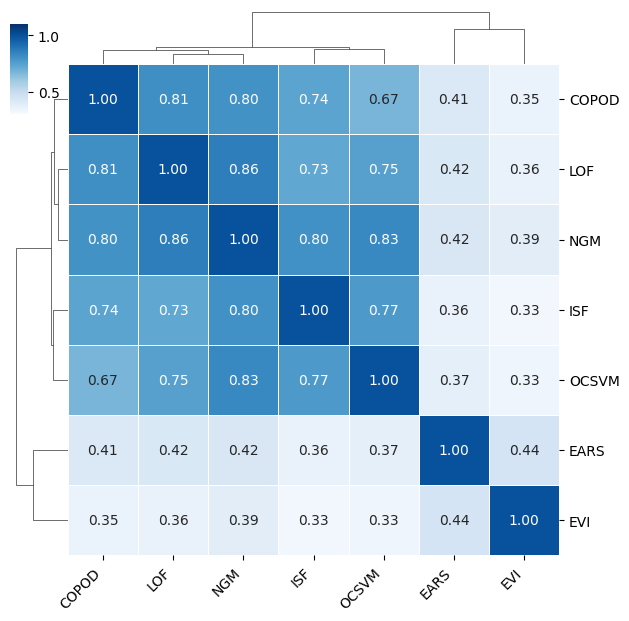

In [26]:
# 1. Definir a cor base (o azul marinho escuro do Lancet)
# Esse tom exato é frequentemente o 'coolwarm' ou 'Blues' com ajuste de contraste
plt.rcParams['font.family'] = 'sans-serif'

# 2. Gerar o Clustermap com a paleta específica
g = sns.clustermap(
    data[models].corr(), 
    annot=True, 
    cmap="Blues",       # Paleta sequencial de azuis
    vmin=0.3,           # Ajustar o mínimo para o azul não sumir (ficar cinza claro)
    vmax=1.1,           # O máximo é o azul marinho saturado
    fmt=".2f", 
    figsize=(6, 6),
    linewidths=.5, 
    dendrogram_ratio=(.1, .1), # Deixa os galhos do dendrograma menores/elegantes
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    annot_kws={"size": 10} # Tamanho dos números dentro dos quadrados
)

# Ajustes de rótulos
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)

plt.savefig('matriz_corr_hier.pdf', dpi=300, bbox_inches='tight')
plt.show()